N# UE01 - Datenvisualisierung & Korrelationsanalyse

Ein Großteil der heutigen Übung wird darauf basieren, die Funktionalität der Bibliothek [matplotlib](https://matplotlib.org/) kennen und diese nutzen zu lernen.
Als genereller Einstieg in die Bibliothek sei [diese extensive Auflistung unterschiedlicher Beispielplots](https://matplotlib.org/stable/gallery/index) zu nennen, die einen Überblick zu den umfangreichen Möglichkeiten von matplotlib gibt. Im Zuge der Abarbeitung der einzelnen Übungsaufgaben können wir uns nur mit einem Teilbereich der Visualisierungsmöglichkeiten beschäftigen und beginnen mit dem Kennenlernen von Histogrammen, Boxplots und Scatterplots.

In [12]:
# Importstatements für die nachfolgenden Übungen sind hier definiert
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.datasets import load_iris
%matplotlib inline

rng = np.random.default_rng(seed=42)

## UE01.a)
Erstellen eines Histogramms der **relativen** Häufigkeit gewürfelter Augenzahlen in <tt>data/dice_rolls.npy</tt> per [NumPy](https://numpy.org/doc/stable/reference/index.html#reference) und anschließendes Anzeigen des Histogramms per matplotlib.
<ol>
    <li>Lade die in UE00.a) generierten Daten in <tt>data/dice_rolls.npy</tt> per <a href="https://numpy.org/doc/stable/reference/generated/numpy.load.html#numpy.load">load()-Funktion von NumPy</a> wieder in die Variable <tt>dice_rolls</tt>.</li>
    <li>Erstelle ein <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">Histogramm per NumPy</a>, das die <strong>relative</strong> Häufigkeit der gewürfelten Augenzahlen in <tt>dice_rolls</tt> darstellt.</li>
    <li>Wieviele <tt>bins</tt> sind für die optimale Darstellung zu wählen? Begründe deine Wahl mit einem kurzen Kommentar.</li>
    <li>Zeige das Histogramm als <a href="https://matplotlib.org/3.5.1/api/_as_gen/matplotlib.pyplot.bar.html">Bar-Chart per matplotlib</a> an.</li>
    <li>Versehe den Plot mit einem entsprechenden Titel sowie korrekten Achsenbeschriftungen für die X-, und Y-Achse.</li>
</ol>

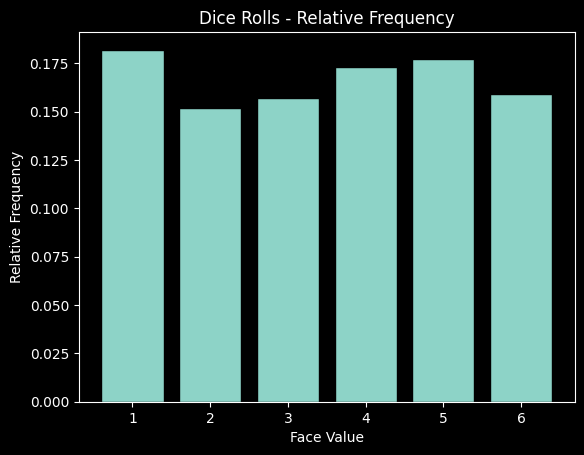

In [11]:
# UE01.a)
import numpy as np
import matplotlib.pyplot as plt

# load data
diceRolls = np.load("data/dice_rolls.npy")

# 6 bins: one per face value (1-6)
counts, binEdges = np.histogram(diceRolls, bins=6, range=(0.5, 6.5))
relFreq = counts / counts.sum()

# bar chart
plt.bar(range(1, 7), relFreq, width=0.8, edgecolor='black')
plt.title("Dice Rolls - Relative Frequency")
plt.xlabel("Face Value")
plt.ylabel("Relative Frequency")
plt.xticks(range(1, 7))
plt.show()

## UE01.b)
Erstellen eines Histogramms der **absoluten** Häufigkeit auftretender Körpergrößen in <tt>data/bodyheight.npy</tt> per matplotlib.
<ol>
    <li>Lade die in UE00.a) generierten Daten, abgespeichert in <tt>data/bodyheight.npy</tt>, per <a href="https://numpy.org/doc/stable/reference/generated/numpy.load.html#numpy.load">load()-Funktion von NumPy</a> wieder in die Variable <tt>bodyheight</tt>.</li>
    <li>Erstelle einen <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html">Histogramm-Plot direkt per matplotlib</a>, der die <strong>absolute</strong> Häufigkeit auftretender Körpergrößen in <tt>bodyheight</tt> darstellt.</li>
    <li>Wähle einen passenden Wert für den Parameter <tt>bins</tt> inkl. kurzem Kommentar zur Begründung der Wahl dieses Parameters.</li>
    <li>Versehe den Plot mit einem entsprechenden Titel sowie korrekten Achsenbeschriftungen für die X-, und Y-Achse.</li>
</ol>

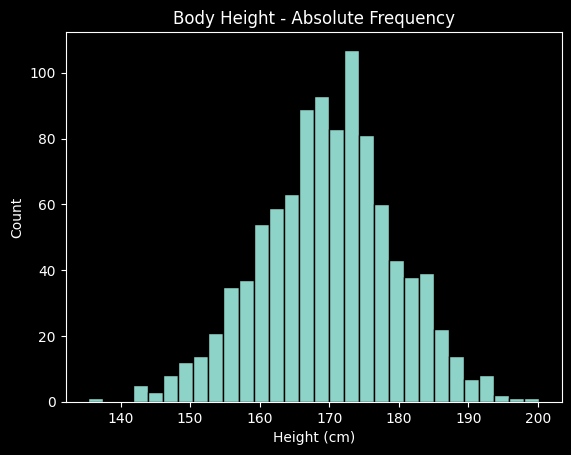

In [10]:
# UE01.b)
import numpy as np
import matplotlib.pyplot as plt

# load data
bodyHeight = np.load("data/bodyheight.npy")

# 30 bins: good balance for n=1000, captures shape without over-smoothing
plt.hist(bodyHeight, bins=30, edgecolor='black')
plt.title("Body Height - Absolute Frequency")
plt.xlabel("Height (cm)")
plt.ylabel("Count")
plt.show()

# UE01.c)
Erstellen eines Histogramms der **relativen** Häufigkeit auftretender Körpergrößen in <tt>data/bodyheight.npy</tt> per matplotlib, zusätzliches Anzeigen der Kurve einer Normalverteilung im selben Plot.
<ol>
    <li>Wiederhole die Schritte aus UE01.b). Plotte diesmal jedoch ein Histrogramm, das die <strong>relative</strong> Häufigkeit auftretender Körpergrößen in <tt>bodyheight</tt> darstellt.</li>
    <li>Plotte die Kurve einer Normalverteilung mit Mittelwert und Standardabweichung berechnet aus der Stichprobe in <tt>bodyheight</tt>.<br>
        Dazu sind folgende Schritte nötig:
        <ul>
            <li>Berechnen von Mittelwert ($\mu$) und Standardabweichung ($\sigma$).</li>
            <li>Festlegen, in welchem Bereich der X-Achse die Kurve zu zeichnen ist.</li>
            <li>Berechnen der Y-Werte der Normalverteilung $N(\mu,\sigma^2)$ für die eben festgelegten X-Werte <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html">(bspw. per scipy)</a>.</li>
            <li>Anzeigen der Normalverteilung im Histogrammplot.</li>
            <li>Zusätzlich ist eine Legende anzuzeigen, in der Normalverteilung und Histogramm ausgewiesen werden.</li>
        </ul>
    </li>
</ol>

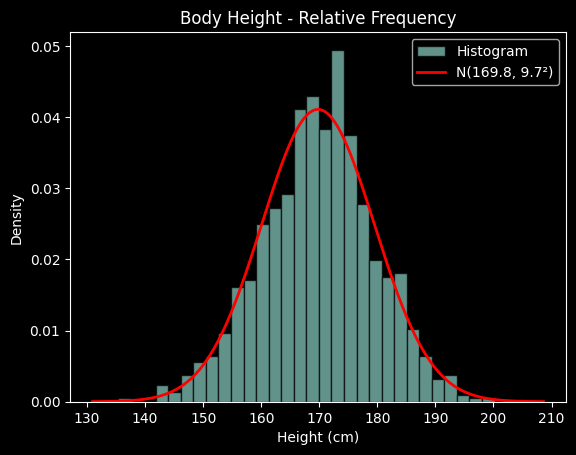

In [13]:
# UE01.c)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# load data
bodyHeight = np.load("data/bodyheight.npy")

# mean & std from sample
mu = np.mean(bodyHeight)
sigma = np.std(bodyHeight)

# relative frequency histogram
plt.hist(bodyHeight, bins=30, density=True, edgecolor='black', alpha=0.7, label='Histogram')

# normal curve over +-4 sigma range
xRange = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
yNorm = stats.norm.pdf(xRange, mu, sigma)
plt.plot(xRange, yNorm, 'r-', linewidth=2, label=f'N({mu:.1f}, {sigma:.1f}²)')

plt.title("Body Height - Relative Frequency")
plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.legend()
plt.show()

## UE01.d)
Erstellen eines Boxplots für Körpergrößen (aus <tt>data/bodyheight.npy</tt>) und Körpergewicht (zu generieren) per matplotlib.
<ol>
    <li>Falls noch nicht geschehen, lade die in UE00.a) generierten Daten, abgespeichert in <tt>data/bodyheight.npy</tt>, per <a href="https://numpy.org/doc/stable/reference/generated/numpy.load.html#numpy.load">load()-Funktion von NumPy</a> wieder in die Variable <tt>bodyheight</tt>.</li>
    <li>Generiere $n = 1000$ Zufallszahlen die einer  <strong> schiefen Normalverteilung</strong> $N(80,10^2)$ mit $\alpha=-4$ folgen.<br>
        Eine Möglichkeit dafür wäre die Verwendung der Klasse <a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewnorm.html">scipy.stats.skewnorm</a>.
        <br>Speichere diese Zufallszahlen in der Variable <tt>bodyweight</tt> sowie der Datei <tt>data/bodyweight.npy</tt>.</li>
    <li>Erstelle <strong>eine</strong> Grafik für die <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html">Boxplots</a> von Körpergröße und Körpergewicht (nebeneinander oder übereinander dargestellt) per matplotlib.</li>
    <li> Achte auf die korrekte Beschriftung (Titel, Datenreihe, etc.) des Boxplots.</li>
    <li> Diskutiere bzw. beschreibe, in Kommentarform oder als Markdownzelle, welche Informationen der Grafik entnommen werden können.</li>
</ol>

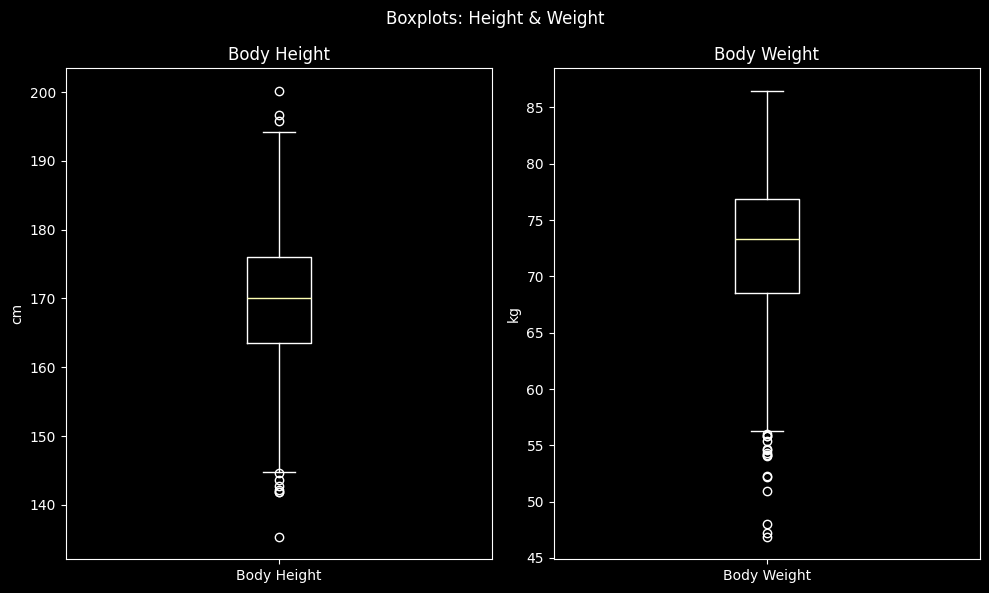

In [14]:
# UE01.d)
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# load data
bodyHeight = np.load("data/bodyheight.npy")

# generate left-skewed body weight: N(80, 10^2), alpha=-4
bodyWeight = stats.skewnorm.rvs(a=-4, loc=80, scale=10, size=1000, random_state=42)
np.save("data/bodyweight.npy", bodyWeight)

# side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].boxplot(bodyHeight, tick_labels=['Body Height'])
axes[0].set_ylabel("cm")
axes[0].set_title("Body Height")
axes[1].boxplot(bodyWeight, tick_labels=['Body Weight'])
axes[1].set_ylabel("kg")
axes[1].set_title("Body Weight")
fig.suptitle("Boxplots: Height & Weight")
plt.tight_layout()
plt.show()

# bodyHeight: symmetric, median ~ mean (~170 cm), whiskers approx equal length, few outliers
# bodyWeight: left-skewed (alpha=-4), median > mean, longer lower whisker, more low-value outliers

## UE01.e)
Scatterplots zweier kontinuierlicher Merkmale des ["Iris"-Beispieldatensatzes](https://archive.ics.uci.edu/ml/datasets/iris) aus [scikit-learn](https://scikit-learn.org/stable/modules/classes.html).
<ol>
    <li>Lade das "Iris"-Datenset über den <a href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html">load_iris() Befehl von scikit-learn</a>, aufzurufen ohne Angabe von Übergabeparametern, in die Variable <tt>iris</tt>.</li>
    <li>In <tt>iris</tt> sind Datenpunkte in der Datenmatrix <tt>data</tt> (2D-NumPy-Array) und die jeweils dazugehörigen Pflanzenklassen im 1D-Array bzw. der Liste <tt>target</tt> abgelegt.
        <ul>
            <li>Greif auf die Datenmatrix <tt>data</tt> zu (ein kleines how-to bietet die oben verlinkte Doku zu <tt>load_iris()</tt>) und gib die Anzahl der Zeilen bzw. Spalten der Datenmatrix <tt>data</tt> aus.</li>
        </ul>
    </li>
    <li>Zeige in zwei <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter">Scatterplots</a> die Beziehungen zwischen unterschiedlichen Spalten des "Iris"-Datensatzes:
        <ul>
            <li>Scatterplot 1 (SP1): Erste Spalte (X-Achse) vs. zweite Spalte (Y-Achse) des Datensatzes.</li>
            <li>Scatterplot 2 (SP2): Dritte Spalte (X-Achse) vs. vierte Spalte (Y-Achse) des Datensatzes.</li>
            <li><strong>Tipp:</strong> Beim Zugriff auf die einzelnen Spalten könnte dieser <a href="https://www.pythoninformer.com/python-libraries/numpy/index-and-slice/">Blogpost</a> hilfreich sein.</li>
            <li>Auch für diese Grafiken ist natürlich auf korrekte Achsenbeschriftungen inkl. Einheiten (siehe <tt>feature_names</tt> in Variable <tt>iris</tt>, Link zum "Iris"-Datensatz oder selbst recherchieren) und entsprechende Titel zu achten.</li>
            <li>Diskutiere bzw. beschreibe, in Kommentarform oder als Markdownzelle, welche Informationen der Grafik entnommen werden können.<br>
                Sind Unterschiede zwischen SP1 und SP2, besonders was den Zusammenhang der beiden aufgezeichneten Merkmale angeht, sichtbar?
            </li>
            <li><strong>Bonus und damit optional:</strong> Verwende die Klassen in <tt>iris.target</tt> zum Einfärben der einzelnen Datenpunkte nach Art der Schwertlilie und zeige eine entsprechende Legende an.</li>
        </ul>
    </li>
</ol>

Rows: 150, Columns: 4


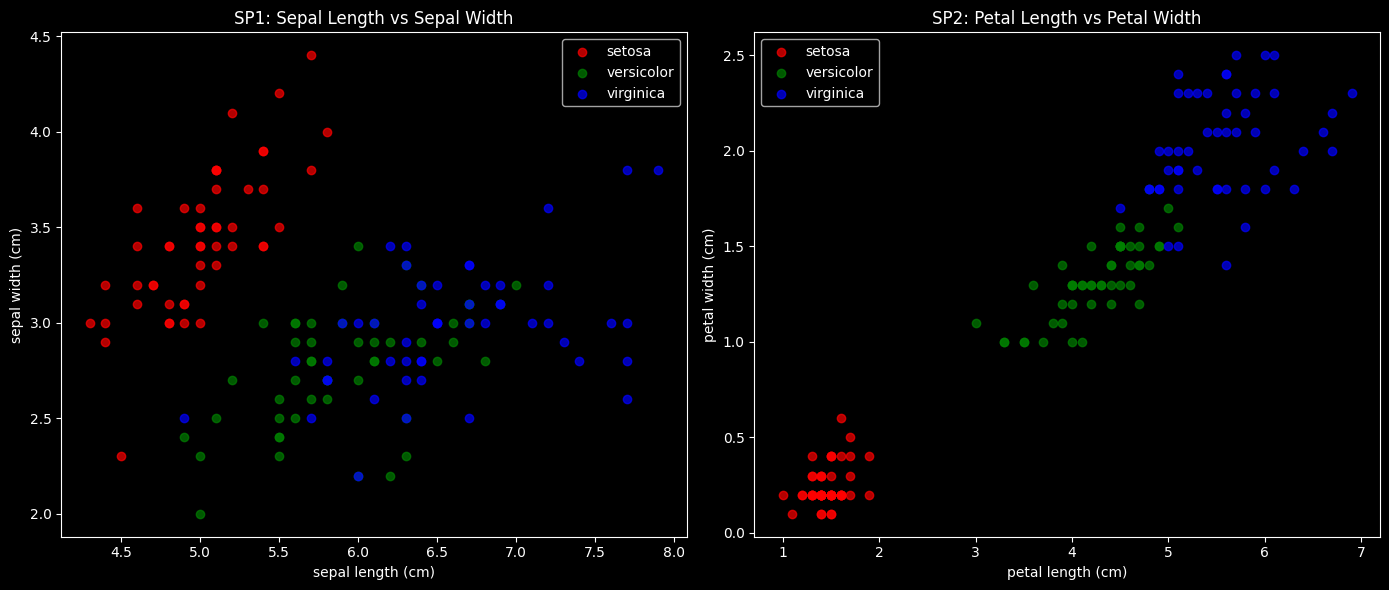

In [7]:
# UE01.e)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# load iris dataset
iris = load_iris()
irisData = iris.data
irisTarget = iris.target
irisClasses = iris.target_names
irisFeatures = iris.feature_names

# shape: rows x columns
print(f"Rows: {irisData.shape[0]}, Columns: {irisData.shape[1]}")

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SP1: col1 (sepal length) vs col2 (sepal width)
for classIdx, className in enumerate(irisClasses):
    mask = irisTarget == classIdx
    axes[0].scatter(irisData[mask, 0], irisData[mask, 1],
                    c=colors[classIdx], label=className, alpha=0.7)
axes[0].set_xlabel(irisFeatures[0])
axes[0].set_ylabel(irisFeatures[1])
axes[0].set_title("SP1: Sepal Length vs Sepal Width")
axes[0].legend()

# SP2: col3 (petal length) vs col4 (petal width)
for classIdx, className in enumerate(irisClasses):
    mask = irisTarget == classIdx
    axes[1].scatter(irisData[mask, 2], irisData[mask, 3],
                    c=colors[classIdx], label=className, alpha=0.7)
axes[1].set_xlabel(irisFeatures[2])
axes[1].set_ylabel(irisFeatures[3])
axes[1].set_title("SP2: Petal Length vs Petal Width")
axes[1].legend()

plt.tight_layout()
plt.show()

# SP1: weak/no clear linear correlation, class overlap -> hard to separate
# SP2: strong positive correlation, clear class separation -> better discriminator

## UE01.f)
Korrelationsanalyse der Merkmale des ["Iris"-Beispieldatensatzes](https://archive.ics.uci.edu/ml/datasets/iris) aus [scikit-learn](https://scikit-learn.org/stable/modules/classes.html).
<ol>
    <li>Falls noch nicht geschehen, lade das "Iris"-Datenset über den <a href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html">load_iris()</a> Befehl von scikit-learn, aufzurufen ohne Angabe von Übergabeparametern, in die Variable <tt>iris</tt>.</li>
    <li>Berechne den Korrelationskoeffizienten über die NumPy Funktion <a href="https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html">corrcoef()</a> zwischen:
        <ul>
            <li>Spalte 1 und Spalte 2 des Datensatzes.</li>
            <li>Spalte 3 und Spalte 4 des Datensatzes.</li>
            <li>Gib den Korrelationskoeffizienten der beiden Spaltenpaare jeweils formattiert aus.</li>
        </ul>
    </li>
    <li>Kommentiere das Ergebnis in Kommentarform oder als Markdownzelle.<br>
        Decken sich die Erkenntnisse, die aus der visuellen Darstellung der Spalten in Scatterplots gewonnen werden können mit den Ergebnissen der Berechnung der Korrelationskoeffizienten?<br>
        Was sagt positive bzw. negative Korrelation aus? Was können wir aus einem Korrelationskoeffizienten von $0$ ableiten?
    </li>
</ol>

In [8]:
# UE01.f)
import numpy as np
from sklearn.datasets import load_iris

# load iris dataset
iris = load_iris()
irisData = iris.data

# correlation: col1 vs col2 (sepal length vs sepal width)
corrSepal = np.corrcoef(irisData[:, 0], irisData[:, 1])

# correlation: col3 vs col4 (petal length vs petal width)
corrPetal = np.corrcoef(irisData[:, 2], irisData[:, 3])

print(f"Corr(col1, col2) - Sepal Length vs Width: {corrSepal[0, 1]:.4f}")
print(f"Corr(col3, col4) - Petal Length vs Width: {corrPetal[0, 1]:.4f}")

# SP1 -> weak negative corr (~-0.12): confirmed by scattered, overlapping points in SP1
# SP2 -> strong positive corr (~0.96): confirmed by clear linear trend in SP2
# positive corr: both features increase together
# negative corr: one increases, other decreases
# corr=0: no linear relationship (non-linear relationship still possible)

Corr(col1, col2) - Sepal Length vs Width: -0.1176
Corr(col3, col4) - Petal Length vs Width: 0.9629
